Visualisasi Sirkuit:


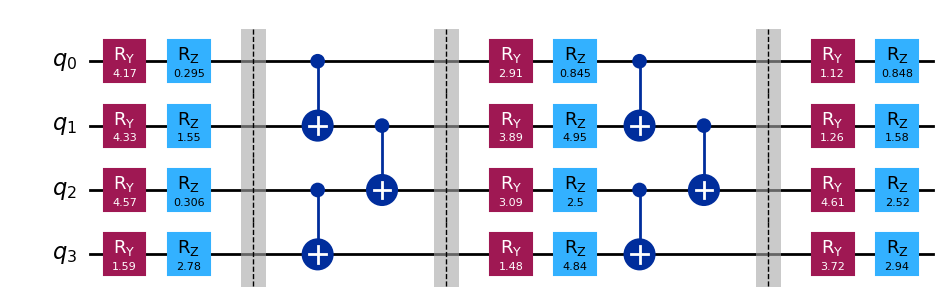

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

def build_vqe_circuit(theta_params):
    """
    Membangun sirkuit VQE sesuai gambar yang Anda berikan.
    Total ada 24 parameter theta (0 sampai 23).
    """
    num_qubits = 4
    qc = QuantumCircuit(num_qubits)

    # --- LAYER 1: Rotasi Awal (SU(2)) ---
    # Ry gates pada semua qubit (theta 0-3)
    for i in range(4):
        qc.ry(theta_params[i], i)
    
    # Rz gates pada semua qubit (theta 4-7)
    for i in range(4):
        qc.rz(theta_params[i+4], i)

    qc.barrier() # Pemisah visual

    # --- LAYER 2: Entanglement Pertama ---
    # Pola: (0->1), (2->3), lalu (1->2)
    qc.cx(0, 1) # q0 kontrol q1
    qc.cx(2, 3) # q2 kontrol q3
    qc.cx(1, 2) # q1 kontrol q2

    qc.barrier()

    # --- BLOCK (Kotak Putus-putus) ---
    # Rotasi lagi (theta 8-11 untuk Ry, 12-15 untuk Rz)
    for i in range(4):
        qc.ry(theta_params[i+8], i)
    for i in range(4):
        qc.rz(theta_params[i+12], i)

    # Entanglement ulang (Pola sama)
    qc.cx(0, 1)
    qc.cx(2, 3)
    qc.cx(1, 2)

    qc.barrier()

    # --- LAYER AKHIR: Rotasi Penutup ---
    # (theta 16-19 untuk Ry, 20-23 untuk Rz)
    for i in range(4):
        qc.ry(theta_params[i+16], i)
    for i in range(4):
        qc.rz(theta_params[i+20], i)

    return qc

# --- SIMULASI ---

# 1. Kita buat 24 parameter sudut acak (sebagai contoh)
# Dalam VQE asli, angka ini yang akan diotak-atik oleh optimizer klasik
params = np.random.rand(24) * 2 * np.pi 

# 2. Bangun Sirkuit
circuit = build_vqe_circuit(params)

# 3. Visualisasikan Sirkuit untuk memastikan strukturnya benar
print("Visualisasi Sirkuit:")
circuit.draw('mpl')

In [3]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

# 1. Definisikan Molekul (H2)
# Atom H pertama di 0,0,0. Atom H kedua berjarak 0.735 Angstrom
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis='sto-3g',
    charge=0,
    spin=0
)

# 2. Dapatkan Masalah Elektronik (Electronic Structure Problem)
problem = driver.run()
hamiltonian_op = problem.hamiltonian.second_q_op()

# 3. Terjemahkan ke Bahasa Qubit (Mapping)
# Menggunakan Jordan-Wigner Mapper
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(hamiltonian_op)

# 4. Lihat Hasilnya (Pauli Strings)
print("Hamiltonian dalam bentuk Pauli Strings:")
print(qubit_hamiltonian)

Hamiltonian dalam bentuk Pauli Strings:
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.17218393+0.j,
 -0.22575349+0.j,  0.12091263+0.j,  0.16892754+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


Target: Mencari Ground State Energy molekul H2...
Hamiltonian memiliki 5 suku Pauli.

Memulai optimasi VQE...
Langkah 10: Energi = -1.51422 Hartree
Langkah 20: Energi = -1.79002 Hartree
Langkah 30: Energi = -1.79459 Hartree
Langkah 40: Energi = -1.82893 Hartree
Langkah 50: Energi = -1.83723 Hartree
Langkah 60: Energi = -1.83782 Hartree
Langkah 70: Energi = -1.83811 Hartree
Langkah 80: Energi = -1.83975 Hartree
Langkah 90: Energi = -1.84055 Hartree
Langkah 100: Energi = -1.84474 Hartree
Langkah 110: Energi = -1.85102 Hartree
Langkah 120: Energi = -1.85361 Hartree
Langkah 130: Energi = -1.85510 Hartree
Langkah 140: Energi = -1.85581 Hartree
Langkah 150: Energi = -1.85637 Hartree
Langkah 160: Energi = -1.85661 Hartree
Langkah 170: Energi = -1.85669 Hartree
Langkah 180: Energi = -1.85682 Hartree
Langkah 190: Energi = -1.85691 Hartree
Langkah 200: Energi = -1.85693 Hartree
Langkah 210: Energi = -1.85696 Hartree
Langkah 220: Energi = -1.85701 Hartree
Langkah 230: Energi = -1.85706 Hartree
La

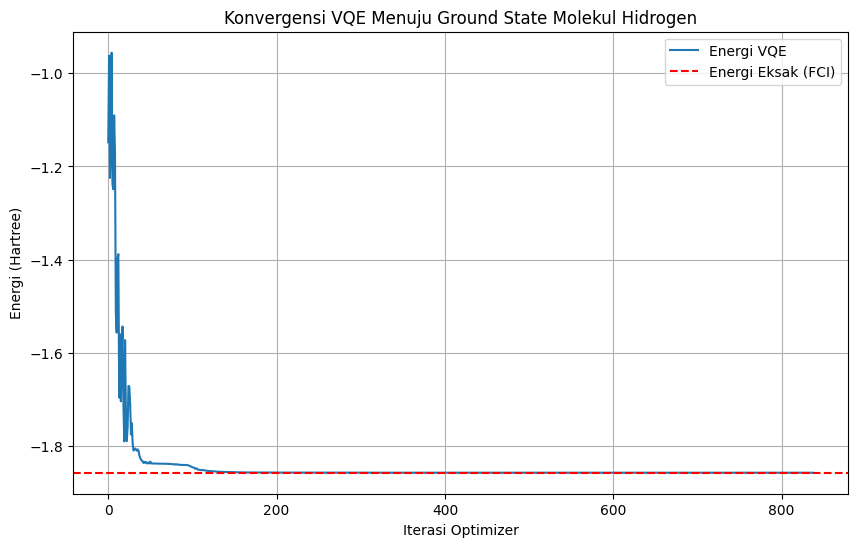

In [7]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
# BAGIAN 1: DEFINISI HAMILTONIAN (H2)
# ==========================================
# Ini adalah Hamiltonian H2 pada jarak antar atom 0.735 Angstrom.
# Angka-angka ini adalah hasil terjemahan dari orbital elektron ke Pauli Strings.
# (Biasanya dihitung otomatis oleh qiskit-nature, tapi kita tulis manual agar simpel).

hamiltonian = SparsePauliOp.from_list([
    ("II", -1.052373245772859),  # Energi dasar (overlap)
    ("IZ",  0.397937424843180),  # Interaksi spin/orbit
    ("ZI", -0.397937424843180),
    ("ZZ", -0.011280104256235),  # Interaksi antar elektron
    ("XX",  0.180931199784231)   # Suku pertukaran (hopping)
])

print("Target: Mencari Ground State Energy molekul H2...")
print(f"Hamiltonian memiliki {len(hamiltonian)} suku Pauli.")

# ==========================================
# BAGIAN 2: SIRKUIT ANSATZ (R_y R_z)
# ==========================================
# Kita gunakan versi 2-Qubit agar sesuai dengan Hamiltonian H2 di atas.
# Pola sama: Rotasi -> CNOT -> Rotasi

def build_ansatz(params):
    qc = QuantumCircuit(2)
    
    # -- Layer 1: Rotasi Awal --
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.rz(params[2], 0)
    qc.rz(params[3], 1)
    
    # -- Layer 2: Entanglement --
    qc.cx(0, 1)
    
    # -- Layer 3: Rotasi Akhir --
    qc.ry(params[4], 0)
    qc.ry(params[5], 1)
    qc.rz(params[6], 0)
    qc.rz(params[7], 1)
    
    return qc

# ==========================================
# BAGIAN 3: FUNGSI BIAYA (COST FUNCTION)
# ==========================================
# Fungsi ini menghubungkan Sirkuit dengan Hamiltonian.
# Input: Parameter sudut (theta)
# Output: Nilai Energi rata-rata

estimator = Estimator() # Simulator matematik Qiskit (Primitive)

energy_history = [] # Untuk menyimpan grafik penurunan energi

def cost_function(params):
    # 1. Bangun sirkuit dengan parameter saat ini
    ansatz = build_ansatz(params)
    
    # 2. Hitung nilai ekspektasi <psi | H | psi>
    # Estimator menghitung probabilitas dan mengalikannya dengan Hamiltonian
    job = estimator.run([(ansatz, hamiltonian)])
    energy = job.result()[0].data.evs
    
    # Simpan untuk plotting
    energy_history.append(energy)
    
    # Print progress setiap 10 langkah (opsional)
    if len(energy_history) % 10 == 0:
        print(f"Langkah {len(energy_history)}: Energi = {energy:.5f} Hartree")
        
    return energy

# ==========================================
# BAGIAN 4: OPTIMIZER (CLASSICAL LOOP)
# ==========================================

print("\nMemulai optimasi VQE...")

# Tebakan awal parameter (8 sudut acak)
initial_params = np.random.rand(8) * 2 * np.pi

# Jalankan Optimizer (COBYLA adalah metode populer yang tidak butuh gradien)
result = minimize(cost_function, initial_params, method='COBYLA', tol=1e-5)

# ==========================================
# BAGIAN 5: HASIL
# ==========================================

print("\n=== HASIL AKHIR ===")
print(f"Energi Minimum Ditemukan: {result.fun:.6f} Hartree")
print(f"Energi Teoritis H2:      -1.857275 Hartree") # Nilai referensi pasti
print(f"Akurasi: {abs(result.fun - (-1.857275)):.6f}")

# Plot Grafik Konvergensi
plt.figure(figsize=(10,6))
plt.plot(energy_history, label='Energi VQE')
plt.axhline(y=-1.857275, color='r', linestyle='--', label='Energi Eksak (FCI)')
plt.xlabel('Iterasi Optimizer')
plt.ylabel('Energi (Hartree)')
plt.title('Konvergensi VQE Menuju Ground State Molekul Hidrogen')
plt.legend()
plt.grid(True)
plt.show()